In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Comparacion

In [ ]:
KNN = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_knn%20(1).csv')

RandomFR = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_rfr.csv')

RotationFR = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_rotationForest.csv')

RotationFR_SL = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_rotationForest_sinLeakage.csv')

RotationFR_SL_NL = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_rotationForest_sinLeakage_NoLineal.csv')

xgb = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_xgb.csv')

In [ ]:
KNN.shape

(6567, 2)

In [ ]:
df = pd.merge(KNN, RandomFR, on='ID', how='inner', suffixes=('_knn', '_rfr'))
df = df.merge(RotationFR, on='ID', how='inner', suffixes=('_rfr', '_rfrot'))
df = df.merge(RotationFR_SL, on='ID', how='inner', suffixes=('_rfrot', '_rfrot_sl'))
df = df.merge(RotationFR_SL_NL, on='ID', how='inner', suffixes=('_rfrot_sl', '_rfrot_sl_nl'))
df = df.merge(xgb, on='ID', how='inner', suffixes=('_rfrot_sl_nl', '_xgb'))

In [ ]:
df.head(1)

,ID,track_popularity_knn,track_popularity_rfr,track_popularity_rfrot,track_popularity_rfrot_sl,track_popularity_rfrot_sl_nl,track_popularity_xgb
0,26266,39.297683,40.24,35.01,36.97,32.65,30.703506


/tmp/ipykernel_1286/3681304246.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], label=f'{col}', shade=True)
/tmp/ipykernel_1286/3681304246.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], label=f'{col}', shade=True)
/tmp/ipykernel_1286/3681304246.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], label=f'{col}', shade=True)
/tmp/ipykernel_1286/3681304246.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], label=f'{col}', shade=True)
/tmp/ipykernel_1286/3681

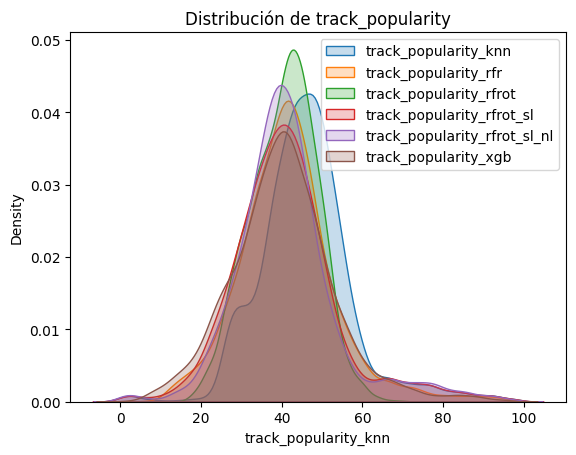

In [ ]:
for col in df.drop(columns=['ID']).columns:
  sns.kdeplot(df[col], label=f'{col}', shade=True)
plt.title(f'Distribución de track_popularity')
plt.legend()

In [ ]:
df['inventada'] = df['track_popularity_rfrot_sl_nl']-5

In [ ]:
df['promedio_best3'] = (df['track_popularity_rfrot_sl_nl']+df['track_popularity_rfrot_sl']+df['track_popularity_rfr'])/3

In [ ]:
df['inventada_menos10'] = df['track_popularity_rfrot_sl_nl']-10
df['inventada_menos10'] = df['inventada_menos10'].apply(lambda x: 0 if x < 0 else x)

/tmp/ipykernel_1286/4294630443.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['inventada'], label=f'inventada_menos5', shade=True)
/tmp/ipykernel_1286/4294630443.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['inventada_menos10'], label=f'inventada_menos10', shade=True)
/tmp/ipykernel_1286/4294630443.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['track_popularity_rfrot_sl_nl'], label=f'track_popularity_rfrot_sl_nl', shade=True)
/tmp/ipykernel_1286/4294630443.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; plea

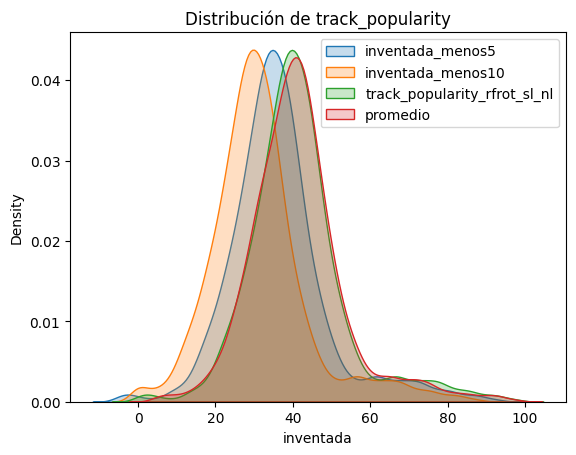

In [ ]:
sns.kdeplot(df['inventada'], label=f'inventada_menos5', shade=True)
sns.kdeplot(df['inventada_menos10'], label=f'inventada_menos10', shade=True)
sns.kdeplot(df['track_popularity_rfrot_sl_nl'], label=f'track_popularity_rfrot_sl_nl', shade=True)
sns.kdeplot(df['promedio_best3'], label=f'promedio', shade=True)

plt.title(f'Distribución de track_popularity')
plt.legend()

Best RotationForest - 5 -> 0,29449

In [ ]:
# df[['ID','inventada']].to_csv('probando_inventada.csv', index=False)

Best RotationForest - 10 -> 0,28478

In [ ]:
# df[['ID','inventada_menos10']].to_csv('BestRotationForest_menos10.csv', index=False)

/tmp/ipykernel_1286/2847981102.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['inventada'], label=f'inventada_menos5', shade=True)
/tmp/ipykernel_1286/2847981102.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['inventada_menos10'], label=f'inventada_menos10', shade=True)
/tmp/ipykernel_1286/2847981102.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['track_popularity_rfrot_sl_nl'], label=f'track_popularity_rfrot_sl_nl', shade=True)
/tmp/ipykernel_1286/2847981102.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; plea

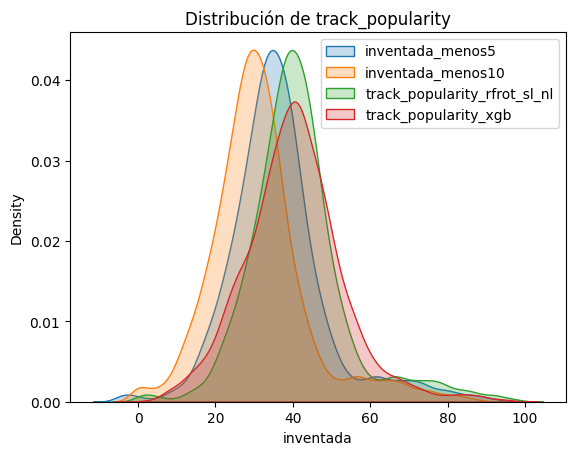

In [ ]:
sns.kdeplot(df['inventada'], label=f'inventada_menos5', shade=True)
sns.kdeplot(df['inventada_menos10'], label=f'inventada_menos10', shade=True)
sns.kdeplot(df['track_popularity_rfrot_sl_nl'], label=f'track_popularity_rfrot_sl_nl', shade=True)
sns.kdeplot(df['track_popularity_xgb'], label=f'track_popularity_xgb', shade=True)

plt.title(f'Distribución de track_popularity')
plt.legend()

XGBoost -> 0,21103

XGBoost corrida 4,5 unidades a la izquierda -> 0,27078

In [ ]:
df['inventada_xgb'] = df['track_popularity_xgb'] - 4.5
df['inventada_xgb'] = df['inventada_xgb'].apply(lambda x: 2.5 if x < 0 else x)
# df[['ID','inventada_xgb']].to_csv('probando_inventada_xgb.csv', index=False)

Sumamos modelos catboost

In [ ]:
catboost0 = pd.read_csv('/content/submission_catboost0.csv')
catboost1_reduced = pd.read_csv('/content/submission_catboost1_reduced.csv')

In [ ]:
df = df.merge(catboost0, on='ID', how='inner', suffixes=('_rfrot_sl_nl', '_catboost0'))
df = df.merge(catboost1_reduced, on='ID', how='inner', suffixes=('_catboost0', '_catboost1_reduced'))

/tmp/ipykernel_1286/3863886105.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['track_popularity_catboost0'], label=f'catboost0', shade=True)
/tmp/ipykernel_1286/3863886105.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['track_popularity_catboost1_reduced'], label=f'catboost1_reduced', shade=True)
/tmp/ipykernel_1286/3863886105.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['track_popularity_rfrot_sl_nl'], label=f'track_popularity_rfrot_sl_nl', shade=True)
/tmp/ipykernel_1286/3863886105.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an err

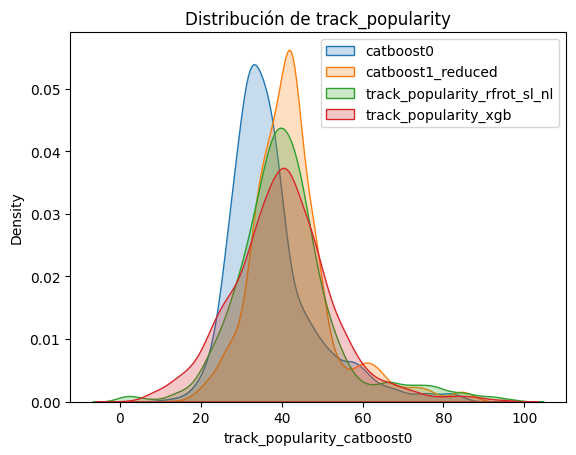

In [ ]:
sns.kdeplot(df['track_popularity_catboost0'], label=f'catboost0', shade=True)
sns.kdeplot(df['track_popularity_catboost1_reduced'], label=f'catboost1_reduced', shade=True)
sns.kdeplot(df['track_popularity_rfrot_sl_nl'], label=f'track_popularity_rfrot_sl_nl', shade=True)
sns.kdeplot(df['track_popularity_xgb'], label=f'track_popularity_xgb', shade=True)

plt.title(f'Distribución de track_popularity')
plt.legend()

### Mejor pred hasta 1/6/26

In [5]:
df_best_pred = pd.read_csv('/content/catboost_full_track_id_imputation_moved-6.25.csv')
df_best_pred['track_popularity'] = (df_best_pred['track_popularity'] + 6.25) - 7
df_best_pred['track_popularity'] = df_best_pred['track_popularity'].apply(lambda x: 0 if x < 0 else x)

df_best_pred.to_csv('catboost_full_track_id_imputation_moved-7.csv', index=False)

### Promedio mejores predicciones (todas las de R^2 score mayor a 0,30)

Saco algunos de los Catboost movidos que son el mismo algoritmo

In [2]:
import os
import pandas as pd

# Directory where the submission files are located
directory_path = '/content/'

# Get a dynamic list of relevant CSV files in the directory
# We'll consider files that contain 'submission' or 'catboost' in their name
# as these are typically the files with 'track_popularity' for averaging.
all_files_in_dir = os.listdir(directory_path)
relevant_csv_files = []
for f in all_files_in_dir:
    if f.endswith('.csv') and ('submission' in f or 'catboost' in f):
        relevant_csv_files.append(os.path.join(directory_path, f))

# Initialize a base dataframe for merging, typically with 'ID'
merged_df = None

print(f"Found {len(relevant_csv_files)} relevant CSV files to average:")
for file_path in relevant_csv_files:
    print(f"- {os.path.basename(file_path)}")
    try:
        temp_df = pd.read_csv(file_path)
        # Ensure 'ID' and 'track_popularity' columns exist
        if 'ID' in temp_df.columns and 'track_popularity' in temp_df.columns:
            # Rename track_popularity to avoid conflicts during merge
            col_name = f'track_popularity_{os.path.basename(file_path).replace(".csv", "")}'
            temp_df = temp_df[['ID', 'track_popularity']].rename(columns={'track_popularity': col_name})

            if merged_df is None:
                merged_df = temp_df
            else:
                # Perform an inner merge to ensure all IDs are common across submissions
                merged_df = pd.merge(merged_df, temp_df, on='ID', how='inner')
        else:
            print(f"Skipping {file_path} as it does not contain 'ID' or 'track_popularity' columns.")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

if merged_df is not None:
    # Get all columns that start with 'track_popularity_'
    popularity_cols = [col for col in merged_df.columns if col.startswith('track_popularity_')]

    if popularity_cols:
        # Calculate the mean of these columns
        merged_df['average_track_popularity'] = merged_df[popularity_cols].mean(axis=1)

        # Display the head of the new DataFrame with averaged predictions
        print("\nDataFrame with averaged 'track_popularity' columns (first 5 rows):")
        print(merged_df[['ID', 'average_track_popularity']].head())

        # Optional: Save the averaged predictions to a new CSV file
        # df_avg_submission = merged_df[['ID', 'average_track_popularity']].rename(columns={'average_track_popularity': 'track_popularity'})
        # df_avg_submission.to_csv('averaged_submission.csv', index=False)
        # print("\nAverages saved to 'averaged_submission.csv'")
    else:
        print("No 'track_popularity' columns found to average after merging.")
else:
    print("No relevant CSV files were found or merged successfully to perform averaging.")

Found 6 relevant CSV files to average:
- catboost_with_leakage.csv
- catboost_with_leakage_moved.csv
- submission_catboost1_reduced_inventada.csv
- catboost_full_plus_with_leakage_track_id_moved6.5.csv
- catboost_full_track_id_imputation_moved-6.25.csv
- submission_catboost0.csv

DataFrame with averaged 'track_popularity' columns (first 5 rows):
      ID  average_track_popularity
0  26266                 29.107257
1  26267                 31.492400
2  26268                 30.683630
3  26269                 28.491468
4  26270                 41.320925


In [4]:
merged_df[['ID', 'average_track_popularity']].rename(columns={'average_track_popularity':'track_popularity'}).to_csv('averaged_submission.csv', index=False)

In [10]:
merged_df.columns

Index(['ID', 'track_popularity_catboost_with_leakage',
       'track_popularity_catboost_with_leakage_moved',
       'track_popularity_submission_catboost1_reduced_inventada',
       'track_popularity_catboost_full_plus_with_leakage_track_id_moved6.5',
       'track_popularity_catboost_full_track_id_imputation_moved-6.25',
       'track_popularity_submission_catboost0', 'average_track_popularity'],
      dtype='object')

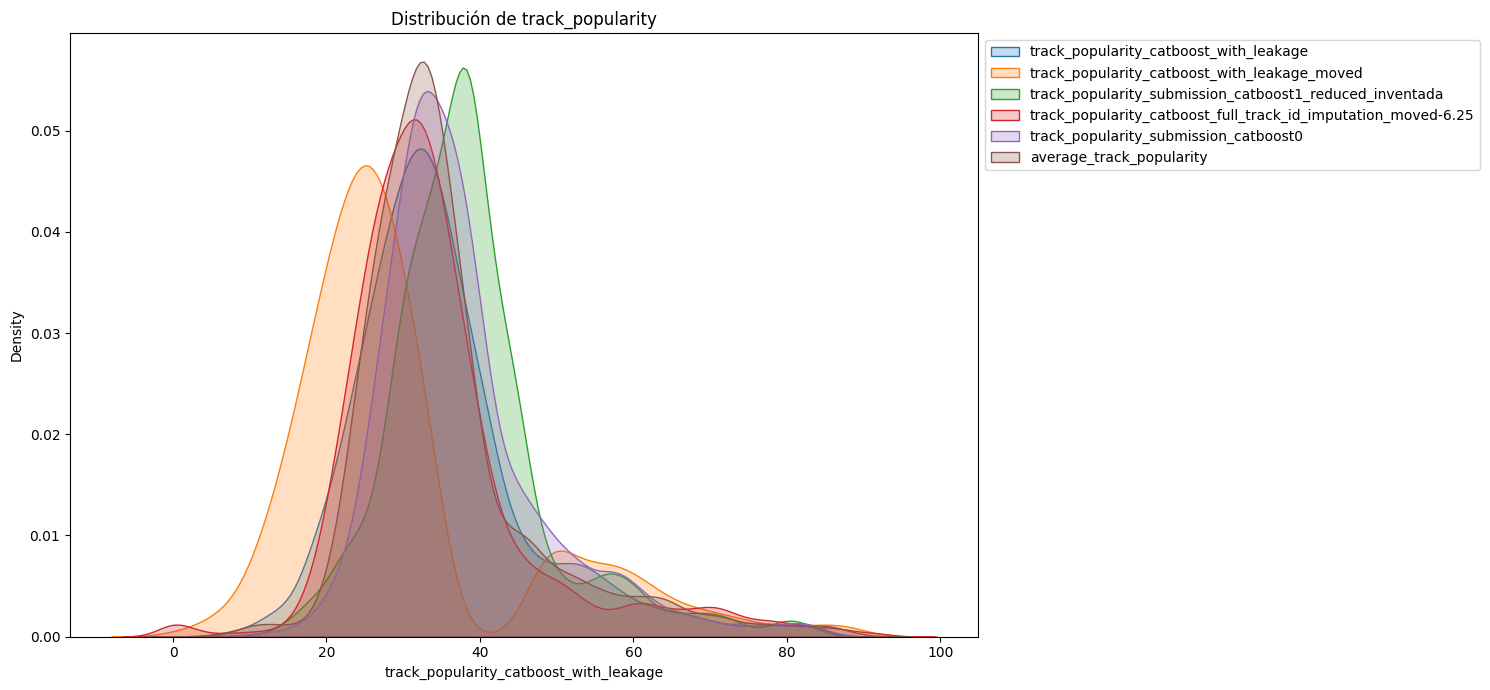

In [20]:
plt.figure(figsize=(15, 7)) # Increased figure size for better legend placement
for col in merged_df.drop(columns=['ID', 'track_popularity_catboost_full_plus_with_leakage_track_id_moved6.5']).columns:
    sns.kdeplot(merged_df[col], label=f'{col}', fill=True)
plt.title(f'Distribución de track_popularity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

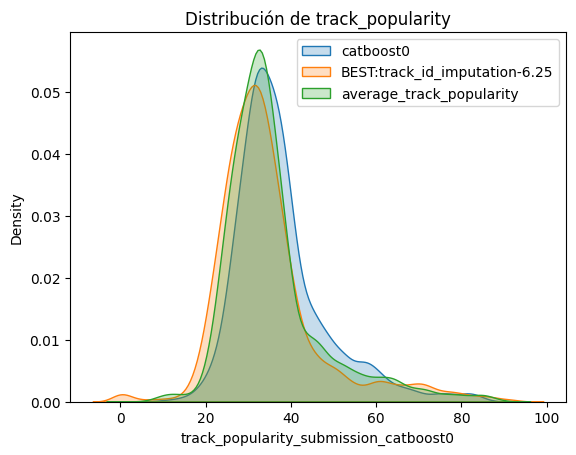

In [23]:
sns.kdeplot(merged_df['track_popularity_submission_catboost0'], label=f'catboost0', fill=True)
sns.kdeplot(merged_df['track_popularity_catboost_full_track_id_imputation_moved-6.25'], label=f'BEST:track_id_imputation-6.25', fill=True)
sns.kdeplot(merged_df['average_track_popularity'], label=f'average_track_popularity', fill=True)
plt.title(f'Distribución de track_popularity')
plt.legend()
plt.show()

### Promedio predicciones (todas arriba de 0,20)

In [26]:
import os
import pandas as pd

# Directory where the files are located
directory_path = '/content/'

# Get all CSV files in the directory
all_files_in_dir = [f for f in os.listdir(directory_path) if f.endswith('.csv')]

# Initialize a base dataframe for merging and a list to track used files
merged_df = None
files_used_for_averaging = []

print(f"Searching for relevant CSV files in '{directory_path}'...")

for filename in all_files_in_dir:
    file_path = os.path.join(directory_path, filename)
    try:
        temp_df = pd.read_csv(file_path)
        # Check if 'ID' column exists
        if 'ID' in temp_df.columns:
            # Check if it has exactly two columns
            if len(temp_df.columns) == 2:
                # Assume the second column is 'track_popularity' if it's not named that already
                if temp_df.columns[1] != 'track_popularity':
                    temp_df.rename(columns={temp_df.columns[1]: 'track_popularity'}, inplace=True)

                # Now proceed as if 'track_popularity' column exists
                col_name = f'track_popularity_{filename.replace(".csv", "")}'
                temp_df = temp_df[['ID', 'track_popularity']].rename(columns={'track_popularity': col_name})

                if merged_df is None:
                    merged_df = temp_df
                else:
                    # Perform an inner merge to ensure all IDs are common across submissions
                    merged_df = pd.merge(merged_df, temp_df, on='ID', how='inner')
                files_used_for_averaging.append(filename)
            else:
                print(f"Skipping '{filename}' as it has {len(temp_df.columns)} columns (expected 2 for ID and track_popularity). A 'track_popularity' column was not explicitly found.")
        else:
            print(f"Skipping '{filename}' as it does not contain an 'ID' column.")
    except Exception as e:
        print(f"Error reading '{filename}': {e}")

if merged_df is not None:
    # Get all columns that start with 'track_popularity_'
    popularity_cols = [col for col in merged_df.columns if col.startswith('track_popularity_')]

    if popularity_cols:
        # Calculate the mean of these columns
        merged_df['average_track_popularity'] = merged_df[popularity_cols].mean(axis=1)

        print("\n--- Files used for averaging ---")
        for f in files_used_for_averaging:
            print(f"- {f}")
        print("---------------------------------")

        # Display the head of the new DataFrame with averaged predictions
        print("\nDataFrame with averaged 'track_popularity' columns (first 5 rows):")
        print(merged_df[['ID', 'average_track_popularity']].head())
    else:
        print("No 'track_popularity' columns found to average after merging.")
else:
    print("No relevant CSV files were found or merged successfully to perform averaging.")

Searching for relevant CSV files in '/content/'...

--- Files used for averaging ---
- catboost_with_leakage.csv
- catboost_full_track_id_imputation_moved-8.csv
- probando_inventada.csv
- catboost_with_leakage_moved.csv
- catboost_full_track_id_imputation_moved-7.csv
- submission_catboost1_reduced_inventada.csv
- BestRotationForest_menos10.csv
- catboost_full_plus_with_leakage_track_id_moved6.5.csv
- catboost_full_track_id_imputation_moved-6.25.csv
- catboost_full_plus_with_leakage_no_0_minus8.5.csv
- submission_catboost0.csv
- submission_catboost2_FE.csv
- probando_inventada_xgb.csv
---------------------------------

DataFrame with averaged 'track_popularity' columns (first 5 rows):
      ID  average_track_popularity
0  26266                 30.113387
1  26267                 33.283219
2  26268                 32.086900
3  26269                 28.668500
4  26270                 35.520854


In [28]:
merged_df[['ID', 'average_track_popularity']].rename(columns={'average_track_popularity':'track_popularity'}).to_csv('averaged_submission_muchas_predicciones.csv', index=False)

Comparamos con el merged anterior

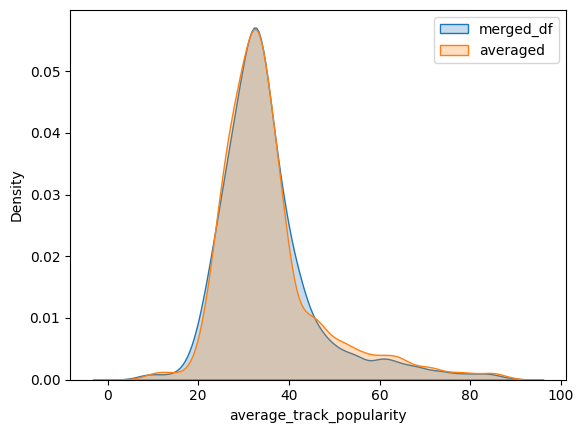

In [31]:
averaged = pd.read_csv('/content/averaged_submission.csv')

sns.kdeplot(merged_df['average_track_popularity'], label=f'merged_df', fill=True)
sns.kdeplot(averaged['track_popularity'], label=f'averaged', fill=True)
plt.legend()
plt.show()

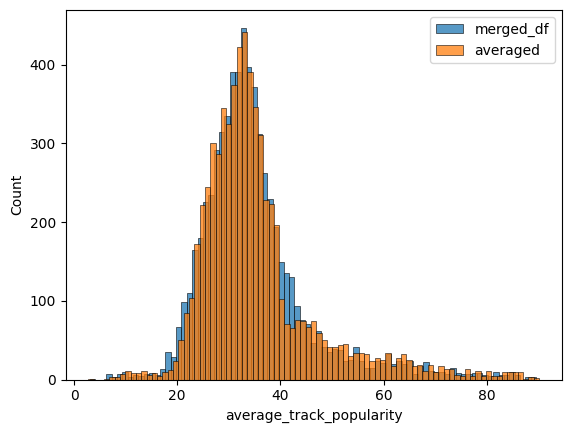

In [33]:
sns.histplot(merged_df['average_track_popularity'], label=f'merged_df')
sns.histplot(averaged['track_popularity'], label=f'averaged')
plt.legend()
plt.show()